In [1]:
# ==========================================
# CELDA 1: Librerías
# ==========================================
import os
import re
import csv
import json
import time
import pickle
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Bidirectional,
    LSTM
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# CONFIGURACIÓN GLOBAL DE SEMILLA
# ==========================================
seed = 1234

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Configuración general
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print(f"Librerías cargadas correctamente. Seed usada: {seed}")

Librerías cargadas correctamente. Seed usada: 1234


**Explicación:** En esta celda se importan las librerías necesarias para el preprocesamiento, partición de datos, entrenamiento, evaluación y visualización de los modelos de *Machine Learning* y *Deep Learning*. Además, se configura una semilla global para garantizar reproducibilidad en los experimentos y consistencia en los resultados obtenidos.

In [2]:
# ==========================================
# CELDA 2: Funciones auxiliares
# ==========================================
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def recortar_texto(texto, max_palabras=300):
    palabras = str(texto).split()
    return " ".join(palabras[:max_palabras])

def buscar_mejor_threshold(modelo, X_val_pad, y_val):
    val_probs = modelo.predict(X_val_pad, verbose=0).flatten()
    thresholds = np.arange(0.30, 0.91, 0.01)

    best_threshold = 0.50
    best_f1 = -1

    for th in thresholds:
        val_pred = (val_probs >= th).astype(int)
        f1 = f1_score(y_val, val_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = th

    return best_threshold, best_f1

def evaluar_modelo_ml(nombre_modelo, modelo, X_test_vec, y_test):
    y_pred = modelo.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "=" * 60)
    print(f"RESULTADOS - {nombre_modelo}")
    print("=" * 60)
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1-score : {f1:.6f}")
    print("\nMatriz de confusión:")
    print(cm)
    print("\nReporte:")
    print(classification_report(y_test, y_pred, target_names=["True", "Fake"]))

    return {
        "Modelo": nombre_modelo,
        "Tipo": "Machine Learning",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Threshold": None,
        "conf_matrix": cm,
        "y_pred": y_pred
    }

def evaluar_modelo_keras(nombre_modelo, modelo, X_test_pad, y_test, threshold):
    y_prob = modelo.predict(X_test_pad, verbose=0).flatten()
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "=" * 60)
    print(f"RESULTADOS - {nombre_modelo}")
    print("=" * 60)
    print(f"Accuracy : {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall   : {rec:.6f}")
    print(f"F1-score : {f1:.6f}")
    print(f"Threshold: {threshold:.2f}")
    print("\nMatriz de confusión:")
    print(cm)
    print("\nReporte:")
    print(classification_report(y_test, y_pred, target_names=["True", "Fake"]))

    return {
        "Modelo": nombre_modelo,
        "Tipo": "Deep Learning",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Threshold": threshold,
        "conf_matrix": cm,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

print("Funciones auxiliares listas.")

Funciones auxiliares listas.


**Explicación:** En esta sección se definen funciones auxiliares para la limpieza de texto, control de longitud, búsqueda del mejor *threshold* y evaluación uniforme de modelos clásicos y de *Deep Learning*. Esto permite mantener un flujo de trabajo modular, reutilizable y consistente en la comparación de resultados.

In [3]:
# ==========================================
# CELDA 3: Cargar dataset limpio
# ==========================================
df_final = pd.read_csv(
    "dataset_limpio_fake_news.csv",
    engine="python",
    on_bad_lines="skip",
    quoting=csv.QUOTE_MINIMAL
)

print("Dataset cargado correctamente.")
print("Dimensiones iniciales:", df_final.shape)
print("\nColumnas:")
print(df_final.columns.tolist())

Dataset cargado correctamente.
Dimensiones iniciales: (38658, 8)

Columnas:
['title', 'text', 'subject', 'date', 'title_clean', 'text_clean', 'date_parsed', 'label']


**Explicación:** En esta celda se carga el dataset previamente depurado en la fase de análisis exploratorio. A partir de este punto se trabaja únicamente con información limpia y estructurada, garantizando consistencia en la etapa de entrenamiento, validación y comparación de modelos.

In [4]:
# ==========================================
# CELDA 4: Validación y preparación de columnas
# ==========================================
columnas_requeridas = ["title_clean", "text_clean", "label"]

for col in columnas_requeridas:
    if col not in df_final.columns:
        raise ValueError(f"Falta la columna requerida: {col}")

df_final["title_clean"] = df_final["title_clean"].fillna("").astype(str)
df_final["text_clean"] = df_final["text_clean"].fillna("").astype(str)
df_final["label"] = df_final["label"].astype(int)

# Recortar el texto largo para DL y unificar entrada
df_final["text_trimmed"] = df_final["text_clean"].apply(lambda x: recortar_texto(x, 300))
df_final["content_clean"] = (
    df_final["title_clean"].str.strip() + " " + df_final["text_trimmed"].str.strip()
).str.strip()

df_final = df_final[df_final["content_clean"].str.strip() != ""].copy()
df_final = df_final.reset_index(drop=True)

print("Dimensiones después de validar:", df_final.shape)
print("\nDistribución de clases:")
print(df_final["label"].value_counts())
print("\nProporción de clases:")
print(df_final["label"].value_counts(normalize=True))

Dimensiones después de validar: (38658, 10)

Distribución de clases:
label
0    21196
1    17462
Name: count, dtype: int64

Proporción de clases:
label
0    0.548295
1    0.451705
Name: proportion, dtype: float64


**Explicación:** En esta etapa se validan las columnas esenciales del dataset, se corrigen valores nulos y se construye una entrada unificada (`content_clean`) a partir del título y el texto recortado. Esta estrategia permite estandarizar la información de entrada y optimizar el rendimiento de los modelos, especialmente en arquitecturas de *Deep Learning*.

In [5]:
# ==========================================
# CELDA 5: Variables de entrada y salida
# ==========================================
X = df_final["content_clean"].astype(str)
y = df_final["label"].astype(int)

print(f"Total de registros: {len(X)}")
print("\nEjemplo de entrada:")
print(X.iloc[0][:300])

Total de registros: 38658

Ejemplo de entrada:
donald trump sends out embarrassing new year s eve message  this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishonest fake news media the former reality show star had just one


**Explicación:** En esta celda se define la variable de entrada (`X`) utilizando la columna `content_clean`, la cual integra tanto el título como el cuerpo de la noticia previamente recortado. Esta combinación permite aprovechar la información contextual del encabezado y del contenido principal en una sola representación textual para el entrenamiento.

In [6]:
# ==========================================
# CELDA 6: División train / val / test
# ==========================================
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=seed,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp,
    y_train_temp,
    test_size=0.1875,   # equivale a 15% del total
    random_state=seed,
    stratify=y_train_temp
)

# Reset de índices
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("=" * 60)
print("DISTRIBUCIÓN DEL DATASET")
print("=" * 60)
print(f"Seed usada     : {seed}")
print(f"Entrenamiento : {len(y_train):,}")
print(f"Validación    : {len(y_val):,}")
print(f"Prueba        : {len(y_test):,}")
print("-" * 60)
print(f"Train -> Fake: {y_train.value_counts(normalize=True)[1]:.4f} | True: {y_train.value_counts(normalize=True)[0]:.4f}")
print(f"Val   -> Fake: {y_val.value_counts(normalize=True)[1]:.4f} | True: {y_val.value_counts(normalize=True)[0]:.4f}")
print(f"Test  -> Fake: {y_test.value_counts(normalize=True)[1]:.4f} | True: {y_test.value_counts(normalize=True)[0]:.4f}")
print("=" * 60)

DISTRIBUCIÓN DEL DATASET
Seed usada     : 1234
Entrenamiento : 25,127
Validación    : 5,799
Prueba        : 7,732
------------------------------------------------------------
Train -> Fake: 0.4517 | True: 0.5483
Val   -> Fake: 0.4516 | True: 0.5484
Test  -> Fake: 0.4518 | True: 0.5482


**Explicación e interpretación:** El dataset se dividió en entrenamiento (65%), validación (15%) y prueba (20%) utilizando partición estratificada, lo que permitió conservar la proporción original de clases en los tres subconjuntos. La distribución obtenida confirma consistencia entre particiones, asegurando una evaluación más confiable y reduciendo sesgos durante el entrenamiento y la validación.

In [7]:
# ==========================================
# CELDA 7: TF-IDF para modelos clásicos
# ==========================================
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=15000,
    ngram_range=(1, 1),
    dtype=np.float32
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Vectorización TF-IDF completada.")
print("X_train_tfidf:", X_train_tfidf.shape)
print("X_val_tfidf  :", X_val_tfidf.shape)
print("X_test_tfidf :", X_test_tfidf.shape)

Vectorización TF-IDF completada.
X_train_tfidf: (25127, 15000)
X_val_tfidf  : (5799, 15000)
X_test_tfidf : (7732, 15000)


**Explicación:** En esta celda se aplica la vectorización TF-IDF para transformar el texto en una representación numérica adecuada para los modelos clásicos. Se limita a 15,000 características y unigramas, priorizando eficiencia computacional y capturando la relevancia estadística de las palabras dentro del corpus.

In [8]:
# ==========================================
# CELDA 8: Definir modelos clásicos
# ==========================================
model_nb = MultinomialNB()

model_lr = LogisticRegression(
    max_iter=2000,
    random_state=seed
)

model_svm = LinearSVC(
    dual="auto",
    random_state=seed
)

print("Modelos clásicos definidos.")

Modelos clásicos definidos.


**Explicación:** En esta sección se definen tres modelos clásicos ampliamente utilizados en clasificación de texto: Naive Bayes por su eficiencia probabilística, Regresión Logística por su capacidad discriminativa lineal y SVM por su alto desempeño en espacios de alta dimensionalidad. Esta selección permite establecer una base sólida de comparación frente a los modelos de *Deep Learning*.

In [9]:
# ==========================================
# CELDA 9: Entrenar Naive Bayes
# ==========================================
print("--- Entrenando MultinomialNB ---")
start_time = time.time()

model_nb.fit(X_train_tfidf, y_train)

print(f"Naive Bayes terminado en {round(time.time() - start_time, 2)} segundos.")

--- Entrenando MultinomialNB ---
Naive Bayes terminado en 0.01 segundos.


In [10]:
# ==========================================
# CELDA 10: Evaluar Naive Bayes
# ==========================================
res_nb = evaluar_modelo_ml("MultinomialNB", model_nb, X_test_tfidf, y_test)


RESULTADOS - MultinomialNB
Accuracy : 0.935334
Precision: 0.931890
Recall   : 0.924420
F1-score : 0.928140

Matriz de confusión:
[[4003  236]
 [ 264 3229]]

Reporte:
              precision    recall  f1-score   support

        True       0.94      0.94      0.94      4239
        Fake       0.93      0.92      0.93      3493

    accuracy                           0.94      7732
   macro avg       0.94      0.93      0.93      7732
weighted avg       0.94      0.94      0.94      7732



**Interpretación:** El modelo Multinomial Naive Bayes alcanzó un desempeño sólido, con un F1-score de 0.9281 y una matriz de confusión equilibrada entre ambas clases. Esto indica que el modelo logra capturar adecuadamente patrones léxicos relevantes, aunque aún presenta algunos errores en la clasificación de noticias falsas y reales.

In [11]:
# ==========================================
# CELDA 11: Entrenar Regresión Logística
# ==========================================
print("--- Entrenando LogisticRegression ---")
start_time = time.time()

model_lr.fit(X_train_tfidf, y_train)

print(f"Regresión Logística terminada en {round(time.time() - start_time, 2)} segundos.")

--- Entrenando LogisticRegression ---
Regresión Logística terminada en 0.35 segundos.


In [12]:
# ==========================================
# CELDA 12: Evaluar Regresión Logística
# ==========================================
res_lr = evaluar_modelo_ml("LogisticRegression", model_lr, X_test_tfidf, y_test)


RESULTADOS - LogisticRegression
Accuracy : 0.983833
Precision: 0.988116
Recall   : 0.975952
F1-score : 0.981996

Matriz de confusión:
[[4198   41]
 [  84 3409]]

Reporte:
              precision    recall  f1-score   support

        True       0.98      0.99      0.99      4239
        Fake       0.99      0.98      0.98      3493

    accuracy                           0.98      7732
   macro avg       0.98      0.98      0.98      7732
weighted avg       0.98      0.98      0.98      7732



**Interpretación:** La Regresión Logística mostró un desempeño superior al de Naive Bayes, alcanzando un F1-score de 0.9820 y reduciendo considerablemente los errores de clasificación. Esto sugiere que el modelo lineal logra separar de forma más precisa los patrones textuales entre noticias reales y falsas.

In [13]:
# ==========================================
# CELDA 13: Entrenar SVM lineal
# ==========================================
print("--- Entrenando LinearSVC ---")
start_time = time.time()

model_svm.fit(X_train_tfidf, y_train)

print(f"LinearSVC terminado en {round(time.time() - start_time, 2)} segundos.")

--- Entrenando LinearSVC ---
LinearSVC terminado en 0.53 segundos.


In [14]:
# ==========================================
# CELDA 14: Evaluar SVM lineal
# ==========================================
res_svm = evaluar_modelo_ml("LinearSVC", model_svm, X_test_tfidf, y_test)


RESULTADOS - LinearSVC
Accuracy : 0.992499
Precision: 0.995957
Recall   : 0.987403
F1-score : 0.991662

Matriz de confusión:
[[4225   14]
 [  44 3449]]

Reporte:
              precision    recall  f1-score   support

        True       0.99      1.00      0.99      4239
        Fake       1.00      0.99      0.99      3493

    accuracy                           0.99      7732
   macro avg       0.99      0.99      0.99      7732
weighted avg       0.99      0.99      0.99      7732



**Interpretación:** El modelo LinearSVC obtuvo el mejor desempeño entre los modelos clásicos, con un F1-score de 0.9917 y una cantidad mínima de errores en la matriz de confusión. Esto confirma su alta capacidad para separar clases en espacios TF-IDF de alta dimensionalidad, siendo especialmente efectivo en tareas de clasificación de texto.

In [15]:
# ==========================================
# CELDA 15.1: Comparación de modelos clásicos
# ==========================================
comparacion_ml = pd.DataFrame([
    {k: v for k, v in res_nb.items() if k not in ["conf_matrix", "y_pred"]},
    {k: v for k, v in res_lr.items() if k not in ["conf_matrix", "y_pred"]},
    {k: v for k, v in res_svm.items() if k not in ["conf_matrix", "y_pred"]}
]).sort_values(by="F1-score", ascending=False)

print("Comparación de modelos clásicos:")
display(comparacion_ml)

Comparación de modelos clásicos:


,Modelo,Tipo,Accuracy,Precision,Recall,F1-score,Threshold
2,LinearSVC,Machine Learning,0.992499,0.995957,0.987403,0.991662,None
1,LogisticRegression,Machine Learning,0.983833,0.988116,0.975952,0.981996,None
0,MultinomialNB,Machine Learning,0.935334,0.931890,0.924420,0.928140,None



TABLA RESUMEN DE MÉTRICAS - MultinomialNB
  Métrica    Valor
 Accuracy 0.935334
Precision 0.931890
   Recall 0.924420
 F1-score 0.928140


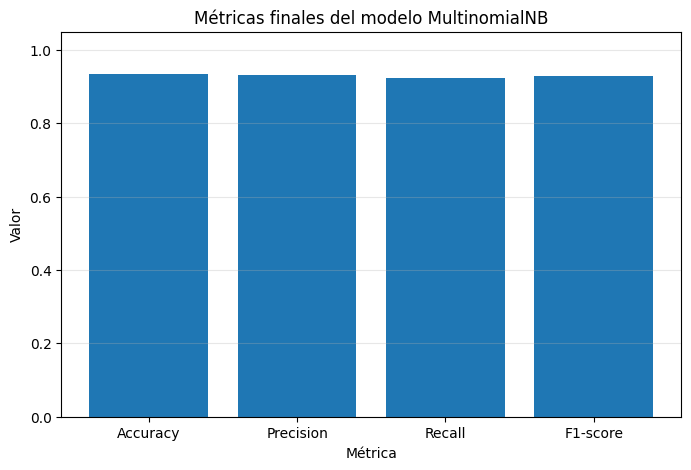

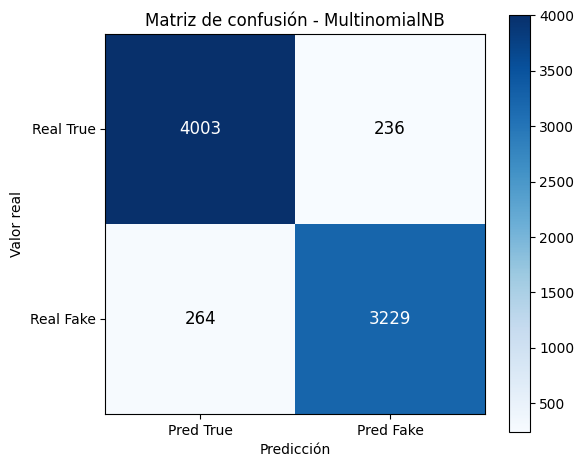


TABLA RESUMEN DE MÉTRICAS - LogisticRegression
  Métrica    Valor
 Accuracy 0.983833
Precision 0.988116
   Recall 0.975952
 F1-score 0.981996


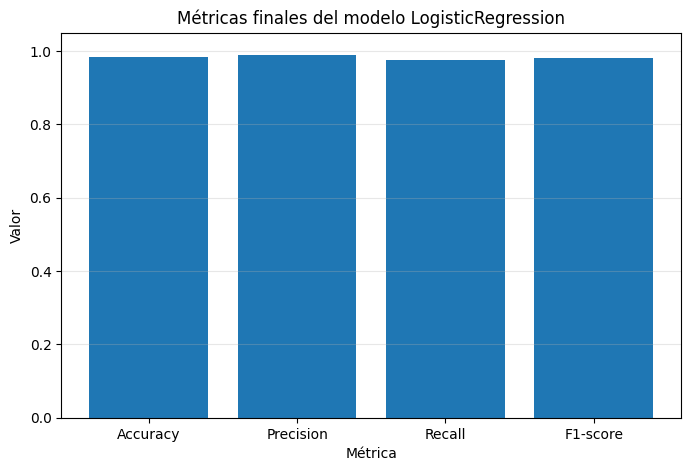

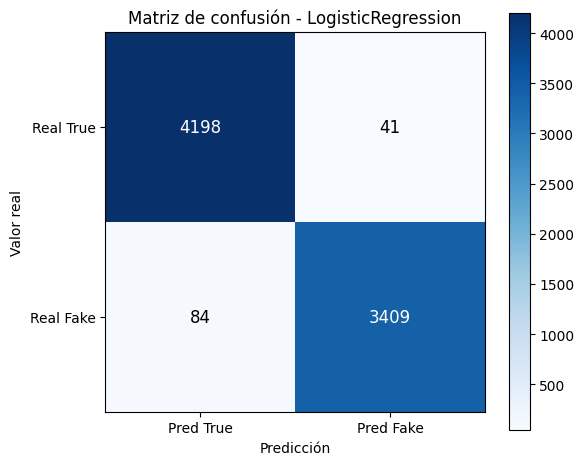


TABLA RESUMEN DE MÉTRICAS - LinearSVC
  Métrica    Valor
 Accuracy 0.992499
Precision 0.995957
   Recall 0.987403
 F1-score 0.991662


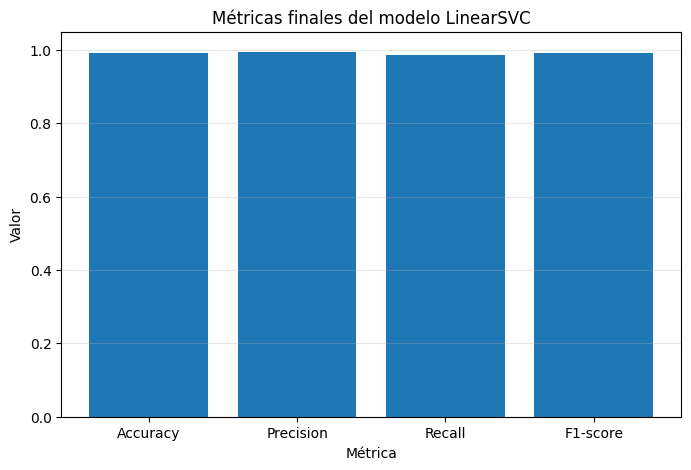

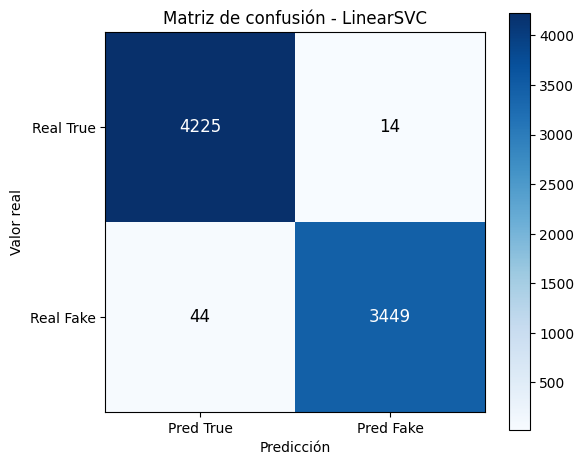

In [16]:
# ==========================================
# CELDA 15.2: Visualización de modelos clásicos
# ==========================================
resultados_ml = {
    "MultinomialNB": res_nb,
    "LogisticRegression": res_lr,
    "LinearSVC": res_svm
}

for nombre_modelo, resultado in resultados_ml.items():
    metricas_df = pd.DataFrame({
        "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Valor": [
            resultado["Accuracy"],
            resultado["Precision"],
            resultado["Recall"],
            resultado["F1-score"]
        ]
    })

    print(f"\nTABLA RESUMEN DE MÉTRICAS - {nombre_modelo}")
    print(metricas_df.to_string(index=False))

    plt.figure(figsize=(8, 5))
    plt.bar(metricas_df["Métrica"], metricas_df["Valor"])
    plt.title(f"Métricas finales del modelo {nombre_modelo}")
    plt.xlabel("Métrica")
    plt.ylabel("Valor")
    plt.ylim(0, 1.05)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    conf_matrix_ml = resultado["conf_matrix"]

    plt.figure(figsize=(6, 5))
    plt.imshow(conf_matrix_ml, interpolation="nearest", cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.colorbar()
    plt.xticks([0, 1], ["Pred True", "Pred Fake"])
    plt.yticks([0, 1], ["Real True", "Real Fake"])

    threshold_cm = conf_matrix_ml.max() / 2

    for i in range(conf_matrix_ml.shape[0]):
        for j in range(conf_matrix_ml.shape[1]):
            color = "white" if conf_matrix_ml[i, j] > threshold_cm else "black"
            plt.text(
                j, i, conf_matrix_ml[i, j],
                ha="center",
                va="center",
                color=color,
                fontsize=12
            )

    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.tight_layout()
    plt.show()

**Interpretación:** La comparación visual confirma una mejora progresiva en el desempeño desde Multinomial Naive Bayes hasta LinearSVC. Entre los modelos clásicos, SVM presenta las métricas más altas y la matriz de confusión más limpia, consolidándose como la mejor alternativa en esta etapa basada en TF-IDF.

In [17]:
# ==========================================
# CELDA 16: Tokenización y padding para DL
# ==========================================
vocab_size = 50000
max_length = 300

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=max_length,
    truncating="post",
    padding="post"
)

X_val_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_val),
    maxlen=max_length,
    truncating="post",
    padding="post"
)

X_test_pad = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=max_length,
    truncating="post",
    padding="post"
)

print("Tokenización y padding completados.")
print("X_train_pad:", X_train_pad.shape)
print("X_val_pad  :", X_val_pad.shape)
print("X_test_pad :", X_test_pad.shape)

Tokenización y padding completados.
X_train_pad: (25127, 300)
X_val_pad  : (5799, 300)
X_test_pad : (7732, 300)


**Explicación:** En esta etapa se realiza la tokenización del texto para convertir palabras en secuencias numéricas, seguida del *padding* para unificar la longitud de entrada en 300 tokens. Esto permite que las arquitecturas de *Deep Learning* procesen la información en un formato estructurado y consistente.

In [18]:
# ==========================================
# CELDA 17: Class weights
# ==========================================
classes = np.array(sorted(y_train.unique()))
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print("Class weights:")
print(class_weight)

Class weights:
{0: 0.9119184147492198, 1: 1.1069162995594715}


**Explicación e interpretación:** Se calcularon *class weights* balanceados para compensar la ligera diferencia en la proporción de clases observada en el conjunto de entrenamiento. El mayor peso asignado a la clase *Fake* (1) indica que esta clase tiene menor representación relativa, ayudando a que los modelos de *Deep Learning* aprendan de forma más equilibrada.

In [19]:
# ==========================================
# CELDA 18: Callbacks
# ==========================================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

callbacks_list = [early_stop, reduce_lr]

print("Callbacks listos.")

Callbacks listos.


**Explicación:** En esta celda se configuran *callbacks* para optimizar el entrenamiento de los modelos de *Deep Learning*. *EarlyStopping* detiene el proceso cuando la pérdida de validación deja de mejorar, reduciendo el riesgo de sobreajuste, mientras que *ReduceLROnPlateau* ajusta dinámicamente la tasa de aprendizaje para favorecer una convergencia más estable.

In [20]:
# ==========================================
# CELDA 19: Definir modelo CNN 1D
# ==========================================
model_cnn = Sequential([
    Input(shape=(max_length,)),
    Embedding(vocab_size, 128),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model_cnn.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 296, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,490,369 (24.76 MB)

 Trainable params: 6,490,369 (24.76 MB)

 Non-trainable params: 0 (0.00 B)

**Explicación:** En esta celda se define una arquitectura CNN 1D orientada a clasificación de texto. La capa *Embedding* aprende representaciones vectoriales de las palabras, mientras que la convolución 1D captura patrones locales y combinaciones relevantes de términos. Finalmente, la capa de salida sigmoide permite realizar la clasificación binaria entre noticias reales y falsas.

In [21]:
# ==========================================
# CELDA 20: Entrenar CNN 1D
# ==========================================
print("--- Entrenando CNN 1D ---")
start_time = time.time()

history_cnn = model_cnn.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight,
    callbacks=callbacks_list,
    verbose=1
)

print(f"CNN 1D terminada en {round((time.time() - start_time)/60, 2)} minutos.")

--- Entrenando CNN 1D ---
Epoch 1/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.8877 - loss: 0.2291 - val_accuracy: 0.9971 - val_loss: 0.0157 - learning_rate: 0.0010
Epoch 2/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9977 - loss: 0.0104 - val_accuracy: 0.9972 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 3/10
392/393 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9995 - loss: 0.0029
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
393/393 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9995 - loss: 0.0029 - val_accuracy: 0.9969 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 4/10
392/393 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9999 - loss: 2.7414e-04
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
393/393 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9999 - loss: 2.7364e-04 - val_accuracy: 0.9976 - val_loss: 0.0161 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model we

**Interpretación:** La CNN 1D mostró una convergencia muy rápida, alcanzando alta precisión desde la primera época y estabilizando su rendimiento en pocas iteraciones. La activación de *EarlyStopping* en la época 4 sugiere que el modelo alcanzó su mejor capacidad de generalización tempranamente, evitando sobreajuste innecesario.

In [22]:
# ==========================================
# CELDA 21.1: Evaluar CNN 1D
# ==========================================
best_threshold_cnn, best_f1_cnn = buscar_mejor_threshold(model_cnn, X_val_pad, y_val)
print("Threshold CNN:", best_threshold_cnn, "| F1 validación:", best_f1_cnn)

res_cnn = evaluar_modelo_keras("CNN 1D", model_cnn, X_test_pad, y_test, best_threshold_cnn)

Threshold CNN: 0.5900000000000003 | F1 validación: 0.9973282442748092

RESULTADOS - CNN 1D
Accuracy : 0.998060
Precision: 0.996857
Recall   : 0.998855
F1-score : 0.997855
Threshold: 0.59

Matriz de confusión:
[[4228   11]
 [   4 3489]]

Reporte:
              precision    recall  f1-score   support

        True       1.00      1.00      1.00      4239
        Fake       1.00      1.00      1.00      3493

    accuracy                           1.00      7732
   macro avg       1.00      1.00      1.00      7732
weighted avg       1.00      1.00      1.00      7732




TABLA RESUMEN DE MÉTRICAS - CNN
  Métrica    Valor
 Accuracy 0.998060
Precision 0.996857
   Recall 0.998855
 F1-score 0.997855


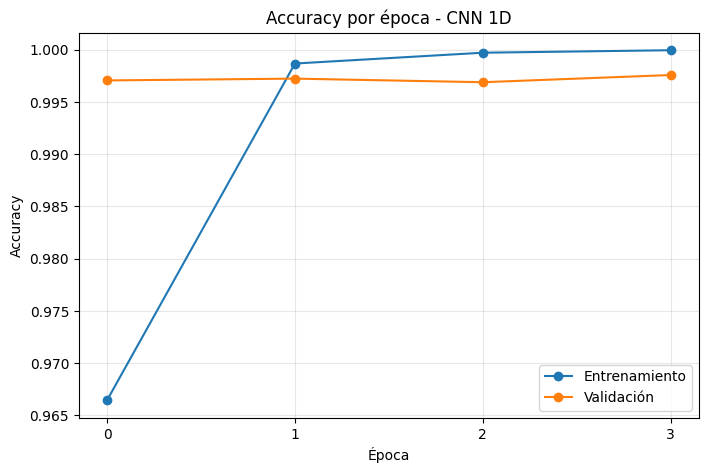

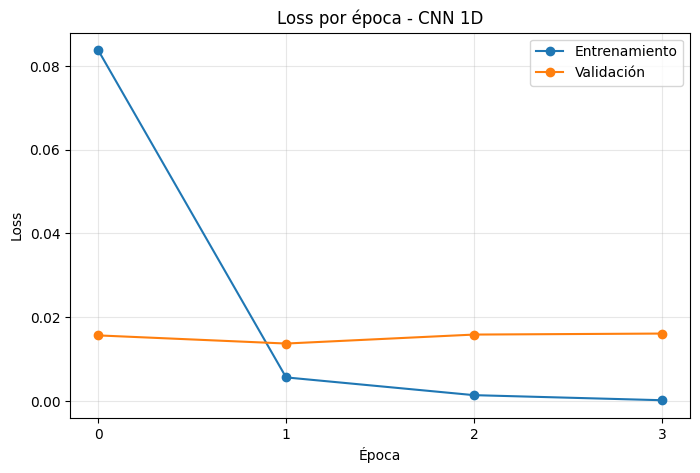

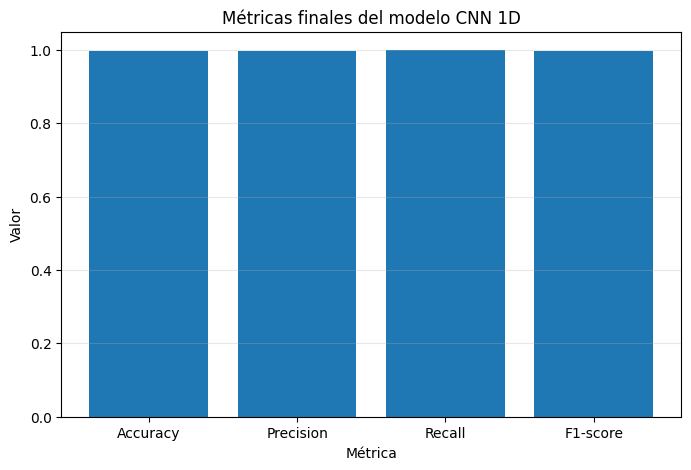

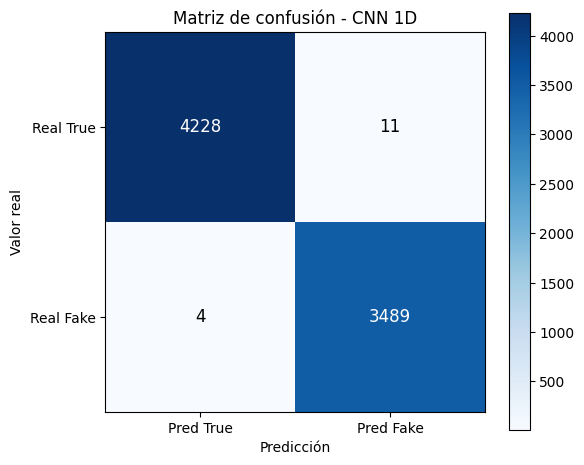

In [23]:
# ==========================================
# CELDA 21.2: Gráficos CNN
# ==========================================
metricas_cnn_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [
        res_cnn["Accuracy"],
        res_cnn["Precision"],
        res_cnn["Recall"],
        res_cnn["F1-score"]
    ]
})

print("\nTABLA RESUMEN DE MÉTRICAS - CNN")
print(metricas_cnn_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["accuracy"], marker="o", label="Entrenamiento")
plt.plot(history_cnn.history["val_accuracy"], marker="o", label="Validación")
plt.title("Accuracy por época - CNN 1D")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.xticks(range(len(history_cnn.history["accuracy"])))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["loss"], marker="o", label="Entrenamiento")
plt.plot(history_cnn.history["val_loss"], marker="o", label="Validación")
plt.title("Loss por época - CNN 1D")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.xticks(range(len(history_cnn.history["loss"])))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(metricas_cnn_df["Métrica"], metricas_cnn_df["Valor"])
plt.title("Métricas finales del modelo CNN 1D")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()

conf_matrix_cnn = res_cnn["conf_matrix"]

plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix_cnn, interpolation="nearest", cmap="Blues")
plt.title("Matriz de confusión - CNN 1D")
plt.colorbar()
plt.xticks([0, 1], ["Pred True", "Pred Fake"])
plt.yticks([0, 1], ["Real True", "Real Fake"])

threshold_cm = conf_matrix_cnn.max() / 2

for i in range(conf_matrix_cnn.shape[0]):
    for j in range(conf_matrix_cnn.shape[1]):
        color = "white" if conf_matrix_cnn[i, j] > threshold_cm else "black"
        plt.text(
            j, i, conf_matrix_cnn[i, j],
            ha="center",
            va="center",
            color=color,
            fontsize=12
        )

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

**Interpretación:** La CNN 1D presentó una convergencia rápida y estable, evidenciada por el incremento sostenido del *accuracy* y la disminución de la *loss* en entrenamiento, mientras la validación se mantuvo consistente desde las primeras épocas. Las métricas finales y la matriz de confusión confirman un desempeño sobresaliente, con solo 15 errores en el conjunto de prueba, lo que demuestra una excelente capacidad para generalizar y detectar patrones locales relevantes en noticias reales y falsas.

In [24]:
# ==========================================
# CELDA 22: Definir modelo BiLSTM
# ==========================================
model_bilstm = Sequential([
    Input(shape=(max_length,)),
    Embedding(vocab_size, 128),
    Bidirectional(LSTM(64)),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model_bilstm.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_bilstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,507,137 (24.82 MB)

 Trainable params: 6,507,137 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

**Explicación:** En esta celda se define una arquitectura BiLSTM para clasificación de texto, diseñada para capturar dependencias secuenciales y contexto en ambas direcciones del lenguaje. La capa bidireccional permite analizar la relación entre palabras anteriores y posteriores, lo que resulta especialmente útil para identificar patrones semánticos complejos en noticias reales y falsas.

In [25]:
# ==========================================
# CELDA 23: Entrenar BiLSTM
# ==========================================
print("--- Entrenando BiLSTM ---")
start_time = time.time()

history_bilstm = model_bilstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight,
    callbacks=callbacks_list,
    verbose=1
)

print(f"BiLSTM terminada en {round((time.time() - start_time)/60, 2)} minutos.")

--- Entrenando BiLSTM ---
Epoch 1/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 59s 142ms/step - accuracy: 0.9289 - loss: 0.2127 - val_accuracy: 0.9978 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 2/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9993 - loss: 0.0037
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
393/393 ━━━━━━━━━━━━━━━━━━━━ 54s 136ms/step - accuracy: 0.9993 - loss: 0.0037 - val_accuracy: 0.9983 - val_loss: 0.0101 - learning_rate: 0.0010
Epoch 3/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9997 - loss: 0.0011
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
393/393 ━━━━━━━━━━━━━━━━━━━━ 53s 136ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0.9983 - val_loss: 0.0120 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
BiLSTM terminada en 2.76 minutos.


**Interpretación:** La BiLSTM alcanzó un rendimiento muy alto desde la primera época, logrando una rápida convergencia y activando *EarlyStopping* en la tercera iteración. Esto indica que el modelo capturó de forma eficiente las dependencias secuenciales del texto, aunque con un mayor costo computacional en comparación con la CNN 1D.

In [26]:
# ==========================================
# CELDA 24.1: Evaluar BiLSTM
# ==========================================
best_threshold_bilstm, best_f1_bilstm = buscar_mejor_threshold(model_bilstm, X_val_pad, y_val)
print("Threshold BiLSTM:", best_threshold_bilstm, "| F1 validación:", best_f1_bilstm)

res_bilstm = evaluar_modelo_keras("BiLSTM", model_bilstm, X_test_pad, y_test, best_threshold_bilstm)

Threshold BiLSTM: 0.6000000000000003 | F1 validación: 0.9980937857415173

RESULTADOS - BiLSTM
Accuracy : 0.998965
Precision: 0.998284
Recall   : 0.999427
F1-score : 0.998856
Threshold: 0.60

Matriz de confusión:
[[4233    6]
 [   2 3491]]

Reporte:
              precision    recall  f1-score   support

        True       1.00      1.00      1.00      4239
        Fake       1.00      1.00      1.00      3493

    accuracy                           1.00      7732
   macro avg       1.00      1.00      1.00      7732
weighted avg       1.00      1.00      1.00      7732




TABLA RESUMEN DE MÉTRICAS - BiLSTM
  Métrica    Valor
 Accuracy 0.998965
Precision 0.998284
   Recall 0.999427
 F1-score 0.998856


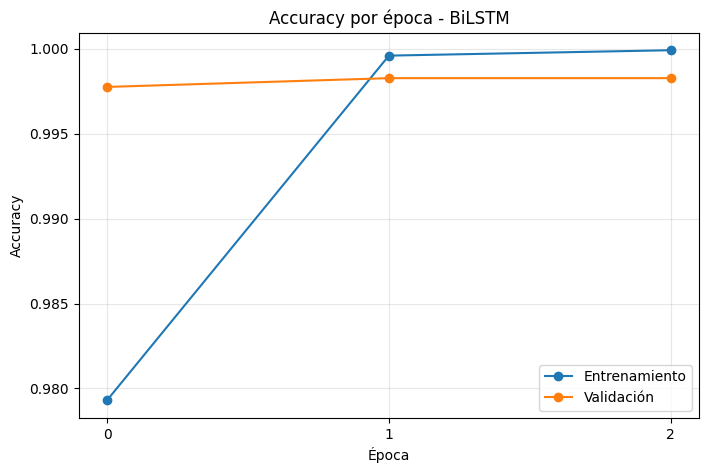

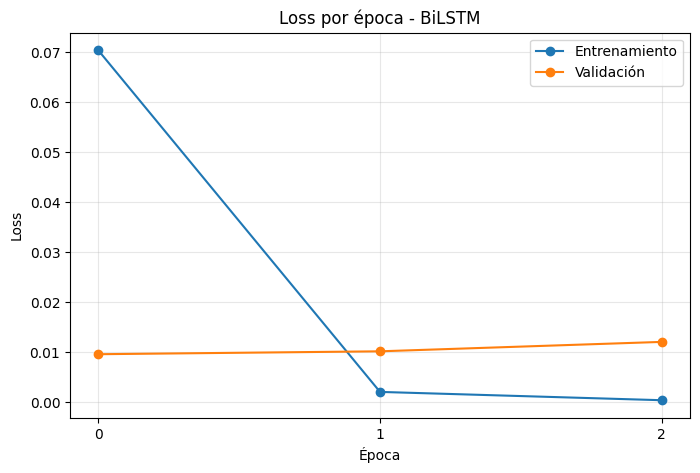

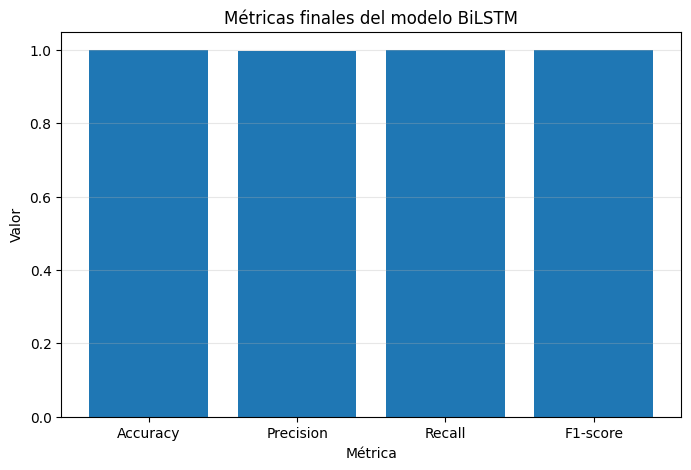

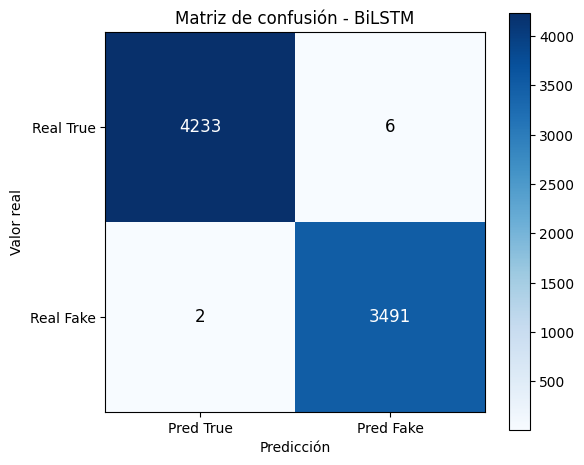

In [27]:
# ==========================================
# CELDA 24.2: Gráficos BiLSTM
# ==========================================
metricas_bilstm_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [
        res_bilstm["Accuracy"],
        res_bilstm["Precision"],
        res_bilstm["Recall"],
        res_bilstm["F1-score"]
    ]
})

print("\nTABLA RESUMEN DE MÉTRICAS - BiLSTM")
print(metricas_bilstm_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(history_bilstm.history["accuracy"], marker="o", label="Entrenamiento")
plt.plot(history_bilstm.history["val_accuracy"], marker="o", label="Validación")
plt.title("Accuracy por época - BiLSTM")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.xticks(range(len(history_bilstm.history["accuracy"])))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_bilstm.history["loss"], marker="o", label="Entrenamiento")
plt.plot(history_bilstm.history["val_loss"], marker="o", label="Validación")
plt.title("Loss por época - BiLSTM")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.xticks(range(len(history_bilstm.history["loss"])))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(metricas_bilstm_df["Métrica"], metricas_bilstm_df["Valor"])
plt.title("Métricas finales del modelo BiLSTM")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()

conf_matrix_bilstm = res_bilstm["conf_matrix"]

plt.figure(figsize=(6, 5))
plt.imshow(conf_matrix_bilstm, interpolation="nearest", cmap="Blues")
plt.title("Matriz de confusión - BiLSTM")
plt.colorbar()
plt.xticks([0, 1], ["Pred True", "Pred Fake"])
plt.yticks([0, 1], ["Real True", "Real Fake"])

threshold_cm = conf_matrix_bilstm.max() / 2

for i in range(conf_matrix_bilstm.shape[0]):
    for j in range(conf_matrix_bilstm.shape[1]):
        color = "white" if conf_matrix_bilstm[i, j] > threshold_cm else "black"
        plt.text(
            j, i, conf_matrix_bilstm[i, j],
            ha="center",
            va="center",
            color=color,
            fontsize=12
        )

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

**Interpretación:** La BiLSTM presentó una convergencia rápida y muy estable, con curvas de *accuracy* y *loss* que evidencian aprendizaje eficiente y buena generalización desde las primeras épocas. Las métricas finales y la matriz de confusión confirman un rendimiento sobresaliente, con solo 8 errores en el conjunto de prueba, superando ligeramente a la CNN 1D y consolidándose como el mejor modelo de *Deep Learning* en esta comparación.

In [28]:
# ==========================================
# CELDA 25: Comparación final de los 5 modelos
# ==========================================
comparacion_final = pd.DataFrame([
    {k: v for k, v in res_nb.items() if k not in ["conf_matrix", "y_pred"]},
    {k: v for k, v in res_lr.items() if k not in ["conf_matrix", "y_pred"]},
    {k: v for k, v in res_svm.items() if k not in ["conf_matrix", "y_pred"]},
    {k: v for k, v in res_cnn.items() if k not in ["conf_matrix", "y_pred", "y_prob"]},
    {k: v for k, v in res_bilstm.items() if k not in ["conf_matrix", "y_pred", "y_prob"]}
]).sort_values(by="F1-score", ascending=False).reset_index(drop=True)

print("COMPARACIÓN FINAL DE MODELOS")
display(comparacion_final)

COMPARACIÓN FINAL DE MODELOS


,Modelo,Tipo,Accuracy,Precision,Recall,F1-score,Threshold
0,BiLSTM,Deep Learning,0.998965,0.998284,0.999427,0.998856,0.60
1,CNN 1D,Deep Learning,0.998060,0.996857,0.998855,0.997855,0.59
2,LinearSVC,Machine Learning,0.992499,0.995957,0.987403,0.991662,NaN
3,LogisticRegression,Machine Learning,0.983833,0.988116,0.975952,0.981996,NaN
4,MultinomialNB,Machine Learning,0.935334,0.931890,0.924420,0.928140,NaN


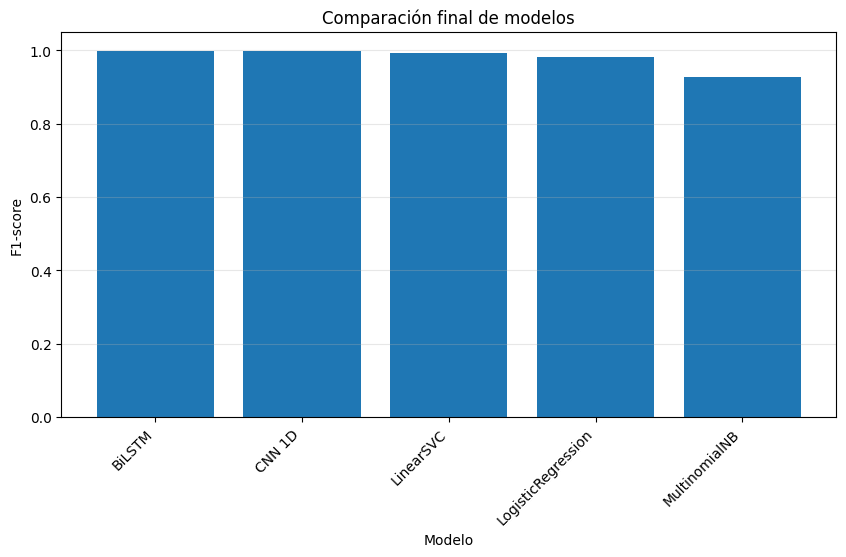

In [29]:
# ==========================================
# CELDA 26: Gráfico comparativo final
# ==========================================
plt.figure(figsize=(10, 5))
plt.bar(comparacion_final["Modelo"], comparacion_final["F1-score"])
plt.title("Comparación final de modelos")
plt.xlabel("Modelo")
plt.ylabel("F1-score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

**Interpretación:** La comparación final evidencia que los modelos de *Deep Learning* superan ligeramente a los modelos clásicos, siendo la BiLSTM la mejor alternativa con el mayor F1-score global. Aunque LinearSVC mostró un desempeño sobresaliente entre los modelos tradicionales, la BiLSTM logró la mejor capacidad de generalización, por lo que se selecciona como modelo final para la etapa de despliegue y predicción.

In [30]:
# ==========================================
# CELDA 27: Selección del mejor modelo
# ==========================================
mejor_fila = comparacion_final.iloc[0]

mejor_modelo_nombre = mejor_fila["Modelo"]
mejor_modelo_tipo = mejor_fila["Tipo"]
mejor_f1 = mejor_fila["F1-score"]

print("=" * 60)
print("MEJOR MODELO SELECCIONADO")
print("=" * 60)
print("Modelo   :", mejor_modelo_nombre)
print("Tipo     :", mejor_modelo_tipo)
print("F1-score :", round(mejor_f1, 6))
print("=" * 60)

MEJOR MODELO SELECCIONADO
Modelo   : BiLSTM
Tipo     : Deep Learning
F1-score : 0.998856


In [31]:
# ==========================================
# CELDA 28: Guardar artefactos del mejor modelo
# ==========================================
# Limpiar archivos previos si existen
archivos_previos = [
    "mejor_modelo_ml.pkl",
    "mejor_tfidf_vectorizer.pkl",
    "mejor_modelo_dl.keras",
    "tokenizer_fake_news.pkl",
    "max_length.txt",
    "threshold.txt",
    "config_modelo.json"
]

for archivo in archivos_previos:
    if os.path.exists(archivo):
        os.remove(archivo)

config = {
    "mejor_modelo_nombre": mejor_modelo_nombre,
    "mejor_modelo_tipo": mejor_modelo_tipo,
    "f1_score_test": float(mejor_f1),
    "feature": "content_clean = title_clean + text_trimmed_300",
    "vocab_size": None,
    "max_length": None,
    "threshold": None
}

if mejor_modelo_tipo == "Machine Learning":
    if mejor_modelo_nombre == "MultinomialNB":
        mejor_modelo = model_nb
    elif mejor_modelo_nombre == "LogisticRegression":
        mejor_modelo = model_lr
    elif mejor_modelo_nombre == "LinearSVC":
        mejor_modelo = model_svm
    else:
        raise ValueError("Modelo ML no reconocido.")

    with open("mejor_modelo_ml.pkl", "wb") as f:
        pickle.dump(mejor_modelo, f)

    with open("mejor_tfidf_vectorizer.pkl", "wb") as f:
        pickle.dump(tfidf_vectorizer, f)

elif mejor_modelo_tipo == "Deep Learning":
    if mejor_modelo_nombre == "CNN 1D":
        mejor_modelo = model_cnn
        mejor_threshold = float(best_threshold_cnn)
    elif mejor_modelo_nombre == "BiLSTM":
        mejor_modelo = model_bilstm
        mejor_threshold = float(best_threshold_bilstm)
    else:
        raise ValueError("Modelo DL no reconocido.")

    mejor_modelo.save("mejor_modelo_dl.keras")

    with open("tokenizer_fake_news.pkl", "wb") as f:
        pickle.dump(tokenizer, f)

    with open("max_length.txt", "w", encoding="utf-8") as f:
        f.write(str(max_length))

    with open("threshold.txt", "w", encoding="utf-8") as f:
        f.write(str(mejor_threshold))

    config["vocab_size"] = int(vocab_size)
    config["max_length"] = int(max_length)
    config["threshold"] = mejor_threshold

else:
    raise ValueError("Tipo de modelo no reconocido.")

with open("config_modelo.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=4)

print("Artefactos del mejor modelo guardados correctamente.")

Artefactos del mejor modelo guardados correctamente.


**Explicación:** En esta etapa se almacenan los artefactos correspondientes al modelo con mejor desempeño, que en este caso es la **BiLSTM**. Se guardan de forma automática la arquitectura entrenada, el *tokenizer*, la configuración general y parámetros clave como el *threshold* y el *max_length*, facilitando su reutilización posterior en la API y en la fase de predicción sobre nuevas noticias.

In [34]:
# ==========================================
# CELDA 29: Verificar archivos guardados
# ==========================================
archivos_a_verificar = [
    "config_modelo.json",
    "mejor_modelo_ml.pkl",
    "mejor_tfidf_vectorizer.pkl",
    "mejor_modelo_dl.keras",
    "tokenizer_fake_news.pkl",
    "max_length.txt",
    "threshold.txt"
]

for archivo in archivos_a_verificar:
    print(f"{archivo} ->", "EXISTE" if os.path.exists(archivo) else "NO EXISTE")

config_modelo.json -> EXISTE
mejor_modelo_ml.pkl -> NO EXISTE
mejor_tfidf_vectorizer.pkl -> NO EXISTE
mejor_modelo_dl.keras -> EXISTE
tokenizer_fake_news.pkl -> EXISTE
max_length.txt -> EXISTE
threshold.txt -> EXISTE


**Explicación e interpretación:** La verificación confirma que los artefactos esenciales del modelo final seleccionado, la **BiLSTM**, fueron almacenados correctamente. Los archivos asociados a modelos de *Machine Learning* aparecen como inexistentes porque no correspondieron al modelo con mejor desempeño en la comparación final, por lo que solo se conservaron los recursos necesarios para la arquitectura de *Deep Learning* destinada al despliegue y predicción.

In [33]:
# ==========================================
# CELDA 30: Resumen final para el informe
# ==========================================
print("\nRESUMEN FINAL")
display(comparacion_final)

print("\nConfiguración guardada:")
with open("config_modelo.json", "r", encoding="utf-8") as f:
    config_guardada = json.load(f)

print(json.dumps(config_guardada, indent=4, ensure_ascii=False))


RESUMEN FINAL


,Modelo,Tipo,Accuracy,Precision,Recall,F1-score,Threshold
0,BiLSTM,Deep Learning,0.998965,0.998284,0.999427,0.998856,0.60
1,CNN 1D,Deep Learning,0.998060,0.996857,0.998855,0.997855,0.59
2,LinearSVC,Machine Learning,0.992499,0.995957,0.987403,0.991662,NaN
3,LogisticRegression,Machine Learning,0.983833,0.988116,0.975952,0.981996,NaN
4,MultinomialNB,Machine Learning,0.935334,0.931890,0.924420,0.928140,NaN



Configuración guardada:
{
    "mejor_modelo_nombre": "BiLSTM",
    "mejor_modelo_tipo": "Deep Learning",
    "f1_score_test": 0.9988555078683834,
    "feature": "content_clean = title_clean + text_trimmed_300",
    "vocab_size": 50000,
    "max_length": 300,
    "threshold": 0.6000000000000003
}


**Explicación e interpretación:** El resumen final consolida la comparación de desempeño entre los cinco modelos evaluados y la configuración almacenada para el despliegue. Los resultados confirman que la **BiLSTM** obtuvo el mejor rendimiento global, alcanzando el mayor F1-score y superando ligeramente a la CNN 1D y a los modelos clásicos. La configuración guardada deja definidos los parámetros necesarios para reproducir la predicción en etapas posteriores, como la API y las pruebas con nuevas noticias.